# Boosting Algorithms

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "showcases":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ml_code.synthetic_data import make_regression, make_classification
from ml_code.model_selection import random_split
from ml_code.metrics import r_squared, f1, residuals_plot, show_confusion_matrix

In [3]:
# Prepare data for regression and classification
x, y = make_classification(n_samples=500, n_features=5, n_classes=2, seed=42)
x_tr_cl, x_te_cl, y_tr_cl, y_te_cl = random_split(x, y, seed=42)

x, y = make_regression(n_samples=500, n_features=5, seed=42)
x_tr_reg, x_te_reg, y_tr_reg, y_te_reg = random_split(x, y, seed=42)

## AdaBoostClassifier

In [4]:
from ml_code.models import AdaBoostClassifier

ada_clf = AdaBoostClassifier(n_models=50, seed=42)
print(ada_clf)

ada_clf.train(x_tr_cl, y_tr_cl)
ada_clf_pred = ada_clf(x_te_cl)
print("f1:", f1(y_te_cl, ada_clf_pred))

AdaBoost(
   n_models=50,
   seed=42,
   trained=False
)
f1: 0.9369482976040353


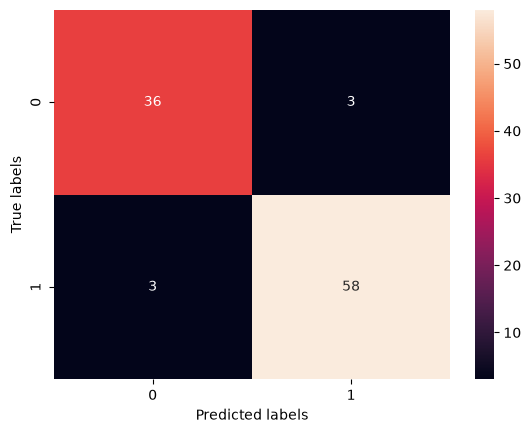

In [5]:
show_confusion_matrix(y_te_cl, ada_clf_pred)

## GradientBoostRegressor 

In [6]:
from ml_code.models import GradientBoostRegressor

gb_reg = GradientBoostRegressor(n_models=20, lr=0.5)
print(gb_reg)

gb_reg.train(x_tr_reg, y_tr_reg)
gb_reg_pred = gb_reg(x_te_reg)
print("R-squared:", r_squared(y_te_reg, gb_reg_pred))

GradientBoostRegressor(
    n_models=20,
    max_depth=3,
    lr=0.5,
    seed=None,
    trained=False
)
R-squared: 0.8885458940165334


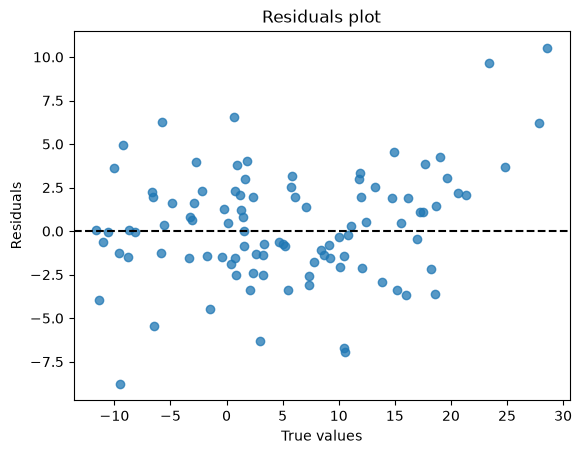

In [7]:
residuals_plot(y_te_reg, gb_reg_pred)

## GradientBoostClassifier

In [8]:
from ml_code.models import GradientBoostClassifier

gb_clf = GradientBoostClassifier(n_models=20, seed=42)
print(gb_clf)

gb_clf.train(x_tr_cl, y_tr_cl)
gb_clf_pred = gb_clf(x_te_cl)
print("f1:", f1(y_te_cl, gb_clf_pred))

GradientBoostClassifier(
    n_models=20,
    max_depth=3,
    lr=0.1,
    seed=42,
    trained=False
)
f1: 0.8406443648984485


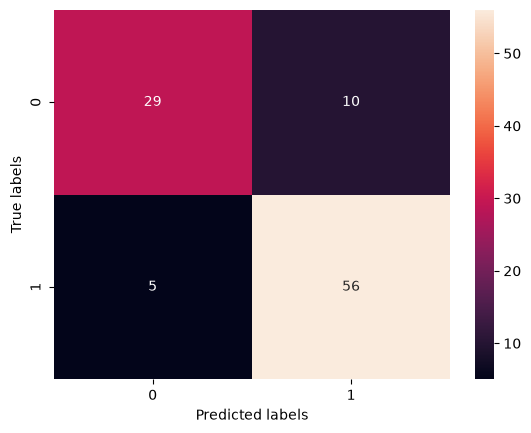

In [9]:
show_confusion_matrix(y_te_cl, gb_clf_pred)

## XGBoostRegressor

In [10]:
from ml_code.models import XGBoostRegressor

xgb_reg = XGBoostRegressor(n_models=20, lr=0.5, lbd=5, gamma=2)
print(xgb_reg)

xgb_reg.train(x_tr_reg, y_tr_reg)
xgb_reg_pred = xgb_reg(x_te_reg)
print("R-squared:", r_squared(y_te_reg, xgb_reg_pred))

XGBoostRegressor(
    n_models=20,
    max_depth=5,
    lr=0.5
    lbd=5
    gamma=2
    seed=None
    trained=False
)
R-squared: 0.9030523042263857


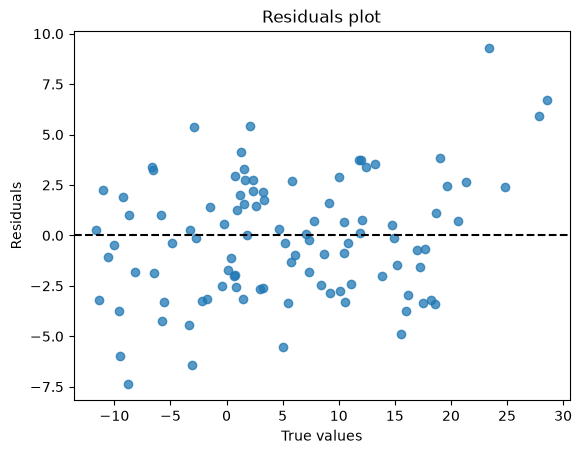

In [11]:
residuals_plot(y_te_reg, xgb_reg_pred)